In [146]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [147]:
def get_single_stock_data(ticker, interval="1d", period="max"):
    df = yf.download(tickers=ticker, interval=interval, period=period, group_by="ticker", auto_adjust=True)
    df.columns = df.columns.droplevel(0)
    df.columns.name = None
    df.columns = df.columns.str.lower()
    df.index.name = 'date'
    return df


In [148]:
df_pep = get_single_stock_data("PEP")
df_ko = get_single_stock_data("KO")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## Inspection 

In [149]:
df_pep

,open,high,low,close,volume
date,,,,,
1972-06-01,0.362516,0.366756,0.362516,0.366756,318600
1972-06-02,0.366757,0.370467,0.365696,0.365696,140400
1972-06-05,0.366759,0.367291,0.354534,0.361444,469800
1972-06-06,0.358255,0.358255,0.357192,0.358255,140400
1972-06-07,0.358255,0.358787,0.355066,0.356129,178200
...,...,...,...,...,...
2026-08-31,139.549211,139.549211,137.857294,138.856613,6555600
2026-09-01,139.697635,139.935088,137.896865,138.312424,5529500
2026-09-02,138.787356,140.212138,137.827608,139.034714,7054500


In [150]:
df_ko

,open,high,low,close,volume
date,,,,,
1962-01-02,0.044457,0.045668,0.044457,0.044457,806400
1962-01-03,0.043797,0.043797,0.042807,0.043467,1574400
1962-01-04,0.043577,0.044127,0.043577,0.043797,844800
1962-01-05,0.043797,0.044347,0.042697,0.042807,1420800
1962-01-08,0.042477,0.042477,0.041541,0.042366,2035200
...,...,...,...,...,...
2026-08-31,89.510002,89.529999,88.599998,88.669998,23764800
2026-09-01,89.589996,89.779999,87.809998,88.000000,14824100
2026-09-02,87.900002,88.949997,87.730003,88.239998,18492800


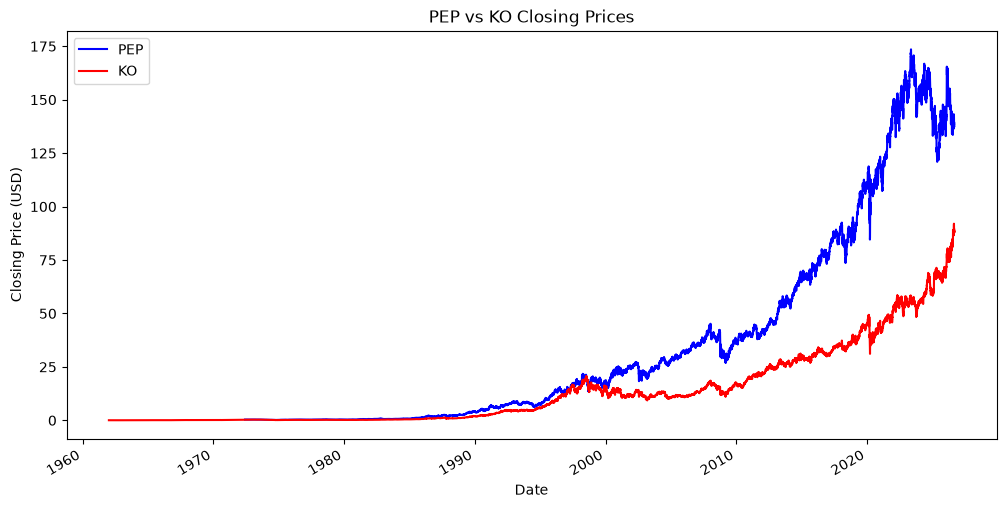

In [151]:
plt.figure(figsize=(12, 6))

df_pep['close'].plot(label='PEP', color='blue')
df_ko['close'].plot(label='KO', color='red')

plt.legend()
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.title('PEP vs KO Closing Prices')

plt.show()

## Completeness Checks

In [152]:
print("First PEP record: ", min(df_pep.index))
print("First KO record: ", min(df_ko.index))

First PEP record:  1972-06-01 00:00:00
First KO record:  1962-01-02 00:00:00


In [153]:
df_ko = df_ko[df_ko.index >= min(df_pep.index)]

In [158]:
df_merged = df_pep.merge(df_ko, on='date', how='outer', suffixes=("_pep", "_ko"), indicator=True)
df_merged.head()

,open_pep,high_pep,low_pep,close_pep,volume_pep,open_ko,high_ko,low_ko,close_ko,volume_ko,_merge
date,,,,,,,,,,,
1972-06-01,0.362516,0.366756,0.362516,0.366756,318600,0.288607,0.289421,0.286706,0.287249,748800,both
1972-06-02,0.366757,0.370467,0.365696,0.365696,140400,0.286707,0.286707,0.285621,0.286164,393600,both
1972-06-05,0.366759,0.367291,0.354534,0.361444,469800,0.286163,0.286706,0.285077,0.285620,662400,both
1972-06-06,0.358255,0.358255,0.357192,0.358255,140400,0.284534,0.284534,0.282634,0.283177,768000,both
1972-06-07,0.358255,0.358787,0.355066,0.356129,178200,0.281819,0.281819,0.279647,0.281819,1420800,both


In [163]:
df_merged.dtypes

open_pep       float64
high_pep       float64
low_pep        float64
close_pep      float64
volume_pep       int64
open_ko        float64
high_ko        float64
low_ko         float64
close_ko       float64
volume_ko        int64
_merge        category
dtype: object

In [154]:
print("PEP only: ", sum(df_merged['_merge'] == 'left_only'))
print("KO only: ", sum(df_merged['_merge'] == 'right_only'))
print("both: ", sum(df_merged['_merge'] == 'both'))

PEP only:  0
KO only:  0
both:  13679


In [174]:
def invalid_checks(df, column):
    print(column, 
          "\n columns: ", len(df_merged[column]),
          "\n positives: ", sum(df_merged[column]>0),
          "\n zeros: ", sum(df_merged[column]==0),
          "\n negatives: ", sum(df_merged[column]<0),
          "\n nulls: ", sum(df_merged[column].isna()),
          "\n"
          )

invalid_checks(df_merged, "close_pep")
invalid_checks(df_merged, "close_ko")

close_pep 
 columns:  13679 
 positives:  13679 
 zeros:  0 
 negatives:  0 
 nulls:  0 

close_ko 
 columns:  13679 
 positives:  13679 
 zeros:  0 
 negatives:  0 
 nulls:  0 



## Saving

In [156]:
df_merged[['close_pep', 'close_ko']].to_csv('../data/pep_ko_daily_close_data.csv', index=True)